## **Mount google drive**
## **Subtask:**
Mount Google Drive to access the image data.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Load and prepare data**
### **Subtask:**
Load the images from the specified folders, preprocess them, and create datasets for training, validation, and testing.

**Reasoning:** Define the paths for the datasets and load and preprocess the images using image_dataset_from_directory to create TensorFlow datasets for training, validation, and testing.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet import preprocess_input
base_dir ="/content/drive/MyDrive/Colab Notebooks/Project_cuoi_khoa/Data_set/"

# Define paths for training, validation, and test sets
train_dir = base_dir + 'training_set'
validation_dir = base_dir + 'validation_set'
test_dir = base_dir + 'test_set'

# Define image size and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32


# Load and preprocess training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Load and preprocess validation data
validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Load and preprocess test data
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Function to scale pixel values to [0, 1]
def preprocess(image, label):
  image = tf.cast(image, tf.float32)
  # nếu ảnh đang ở [0,1] thì nhân lên 255; nếu đã ở [0,255] thì giữ nguyên
  image = tf.cond(tf.reduce_max(image) <= 1.0,
                    lambda: image * 255.0,
                    lambda: image)
  image = preprocess_input(image)   # MobileNet expects 0-255 -> returns ~[-1,1]
  return image, label
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
validation_ds = validation_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("Datasets created successfully:")
print(f"Training dataset: {train_ds}")
print(f"Validation dataset: {validation_ds}")
print(f"Test dataset: {test_ds}")

Found 560 files belonging to 2 classes.
Found 160 files belonging to 2 classes.
Found 240 files belonging to 2 classes.
Datasets created successfully:
Training dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>
Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>
Test dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>



Check data

In [ ]:
# Tạo lại dataset (không map preprocess) chỉ để kiểm tra class_names/hiển thị
raw_train = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    interpolation='bilinear'
)

print("Class names (label index order):", raw_train.class_names)
# Với folder names ['hemmorhage_data','non_hemmorhage_data'],
# label 0 -> 'hemmorhage_data', label 1 -> 'non_hemmorhage_data' (alphabetical order)

Found 560 files belonging to 2 classes.
Found 560 files belonging to 2 classes.
Class names (label index order): ['hemmorhage_data', 'non_hemmorhage_data']
Class names (label index order): ['hemmorhage_data', 'non_hemmorhage_data']


/tmp/ipython-input-2149968258.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(raw_train.class_names[int(labels[i])])
/tmp/ipython-input-2149968258.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(raw_train.class_names[int(labels[i])])


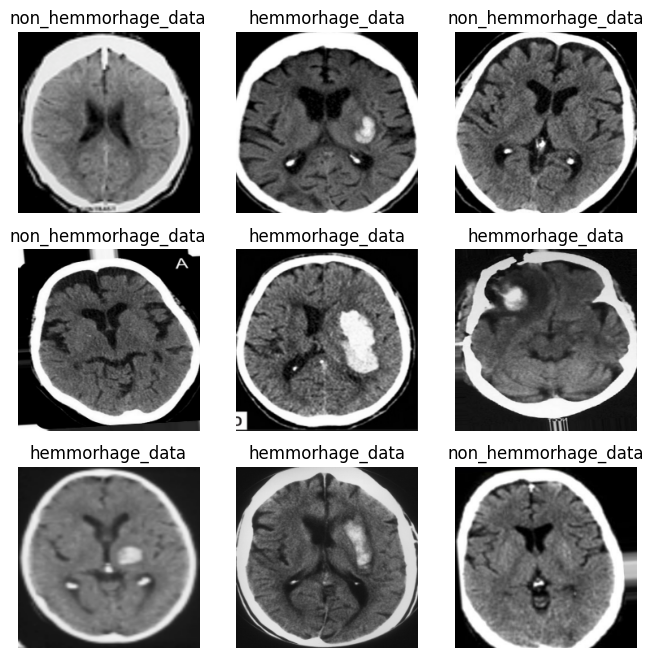

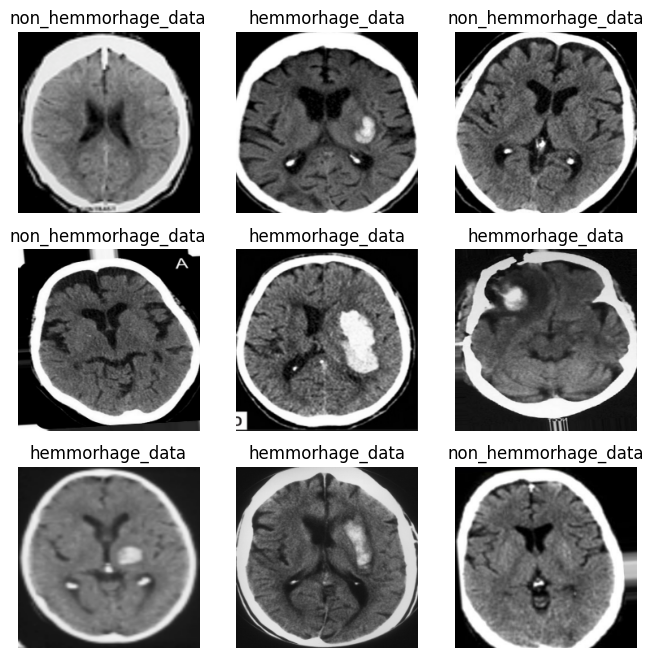

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
for images, labels in raw_train.take(1):   # 1 batch
    images = images.numpy().astype("uint8")
    labels = labels.numpy()
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        plt.title(raw_train.class_names[int(labels[i])])
        plt.axis('off')
plt.show()

In [ ]:
import os
classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Classes in FS (alphabetical):", classes)

for idx, cls in enumerate(classes):
    folder = os.path.join(train_dir, cls)
    sample_files = os.listdir(folder)[:5]
    print(f"Label {idx} -> {cls}, sample files: {sample_files}")


Classes in FS (alphabetical): ['hemmorhage_data', 'non_hemmorhage_data']
Label 0 -> hemmorhage_data, sample files: ['050.png', '061.png', '030.png', '085.png', '082.png']
Label 1 -> non_hemmorhage_data, sample files: ['133.png', '130.png', '134.png', '132.png', '131.png']


In [ ]:
import numpy as np

def count_labels(ds):
    counts = np.zeros(2, dtype=int)
    for images, labels in ds.unbatch():
        counts[int(labels.numpy())] += 1
    return counts

# dùng raw_train hoặc recreate dataset với batch_size lớn để count nhanh:
big = tf.keras.utils.image_dataset_from_directory(train_dir, image_size=(IMG_HEIGHT,IMG_WIDTH), batch_size=1024, shuffle=False)
print("Train label counts:", count_labels(big))


Found 560 files belonging to 2 classes.
Found 560 files belonging to 2 classes.
Train label counts: [280 280]
Train label counts: [280 280]


## **Build and compile the model**
### **Subtask:**
Build a MobileNetV3 model for binary classification and compile it with an appropriate optimizer, loss function, and metrics.

**Reasoning:** Define and compile the MobileNetV1 model using MobileNetV3 from tensorflow.keras.applications with pre-trained weights from ImageNet, and add a dense layer for binary classification. Use Adam optimizer, Binary Crossentropy loss, and Accuracy metric.

In [ ]:
from tensorflow.keras.applications import MobileNetV3Small,MobileNetV3Large,MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model



# Base model
base_model = MobileNetV3Large(weights='imagenet',
                              include_top=False,
                              input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                              include_preprocessing=False)
base_model.trainable = True # Freeze all layers except the last few
for layer in base_model.layers[:-1]:
  layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy',
                       tf.keras.metrics.AUC(name='auc'),
                       tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall')])
model.summary()



Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ input_layer_21[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_394      │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation_394[0… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_365 (ReLU)    │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu_365[0][0]   │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation_394[0… │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_366 (ReLU)    │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_366[0][0]   │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_367 (ReLU)    │ (None, 56, 56,    │          0 │ expanded_conv_1_

 Total params: 2,997,313 (11.43 MB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

## **Train the model**
### **Subtask:**
Train the compiled model using the training and validation datasets.

**Reasoning:** Train the model using the fit method with the training and validation datasets. Specify the number of epochs.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

EPOCHS = 50  # You can adjust the number of epochs

# Define Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1, mode='min',min_delta=0.01) # You can adjust patience
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping] # Add Early Stopping callback
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.5426 - auc: 0.5714 - loss: 0.9264 - precision: 0.5740 - recall: 0.2740 - val_accuracy: 0.5000 - val_auc: 0.2656 - val_loss: 0.9408 - val_precision: 0.5000 - val_recall: 0.0625
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5225 - auc: 0.5217 - loss: 0.9732 - precision: 0.5205 - recall: 0.3488 - val_accuracy: 0.4000 - val_auc: 0.2815 - val_loss: 0.8711 - val_precision: 0.2778 - val_recall: 0.1250
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5483 - auc: 0.5883 - loss: 0.8207 - precision: 0.5502 - recall: 0.4367 - val_accuracy: 0.3750 - val_auc: 0.2999 - val_loss: 0.8413 - val_precision: 0.2619 - val_recall: 0.1375
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.5339 - auc: 0.5446 - loss: 0.8875 - precision: 0.5277 - recall: 0.4570 - val_accuracy: 0.3625 - val_auc: 0.3206 - val_loss: 0.8215 - val_precision: 0.2708 - val_recall: 0.1625
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━

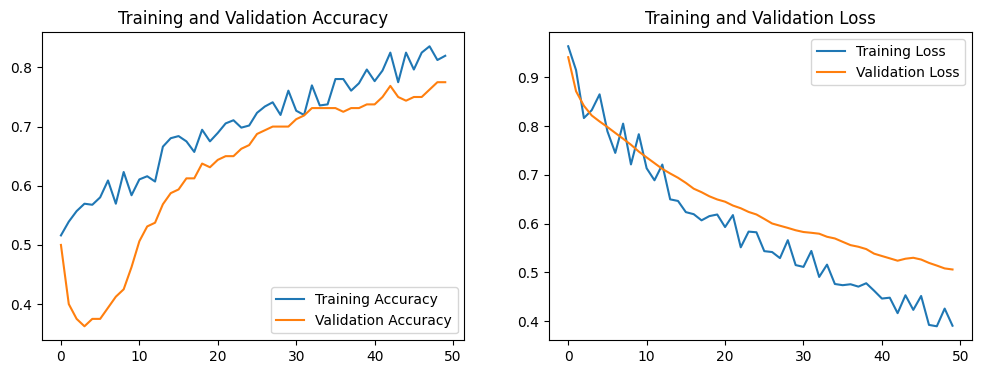

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(50)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## **Evaluate the model**
### **Subtask:**
Evaluate the trained model using the test dataset to assess its performance on unseen data.

**Reasoning:** Evaluate the trained model on the test dataset using the evaluate method to determine its loss and accuracy on unseen data.

In [ ]:
# Evaluate the model on the test set
probs = model.predict(test_ds).ravel()   # (N,)
results = model.evaluate(test_ds)
y_true = np.concatenate([y.numpy().reshape(-1) for x, y in test_ds], axis=0)

# Access the metrics by name from the model's metrics list
metric_names = model.metrics_names
for name, value in zip(metric_names, results):
    print(f"Test {name.capitalize()}: {value}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 651ms/step - accuracy: 0.8730 - auc: 0.6312 - loss: 0.3760 - precision: 0.5134 - recall: 0.5594
Test Loss: 0.39817488193511963
Test Compile_metrics: 0.8333333134651184



## **Make predictions**
### **Subtask:**
Make predictions on the test dataset using the trained model.

**Reasoning:** Use the predict method to generate predictions for the test dataset.

In [ ]:
# Make predictions on the test set
predictions = model.predict(test_ds)
# Unpack all returned metrics from model.evaluate
loss, accuracy, auc, precision, recall = model.evaluate(test_ds)
print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")
print(f"Test AUC: {auc:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7813 - auc: 0.5924 - loss: 0.4761 - precision: 0.4276 - recall: 0.5698
Test loss: 0.4819
Test accuracy: 0.7875
Test AUC: 0.8547
Test Precision: 0.7851
Test Recall: 0.7917


## **Visualize training results**
### **Subtask:**
Visualize the training and validation accuracy and loss over epochs.

In [ ]:
# --- Imports cần thiết ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)
fpr, tpr, roc_th = roc_curve(y_true, probs)
roc_auc = roc_auc_score(y_true, probs)

target_recall = 0.98

# Tìm các indices thỏa TPR >= target_recall
candidates = np.where(tpr >= target_recall)[0]

if candidates.size == 0:
    # Không có threshold nào đạt target_recall -> fallback: chọn threshold có TPR cao nhất
    idx = int(np.argmax(tpr))
    chosen_threshold = float(roc_th[idx])
    fallback = True
    msg = (f"Không tìm được threshold nào với Recall >= {target_recall:.2f}. "
           f"Falling back to threshold with highest TPR = {tpr[idx]:.4f}")
else:
    # Trong các candidate, chọn index có FPR nhỏ nhất (ít false positive nhất)
    sub_fpr = fpr[candidates]
    best_sub_idx = np.argmin(sub_fpr)
    idx = int(candidates[best_sub_idx])
    chosen_threshold = float(roc_th[idx])
    fallback = False
    msg = (f"Found threshold for Recall >= {target_recall:.2f}: threshold = {chosen_threshold:.4f}, "
           f"TPR = {tpr[idx]:.4f}, FPR = {fpr[idx]:.4f}")

print(msg)

Found threshold for Recall >= 0.98: threshold = 0.2056, TPR = 0.9833, FPR = 0.6583


History keys: ['accuracy', 'auc', 'loss', 'precision', 'recall', 'val_accuracy', 'val_auc', 'val_loss', 'val_precision', 'val_recall']


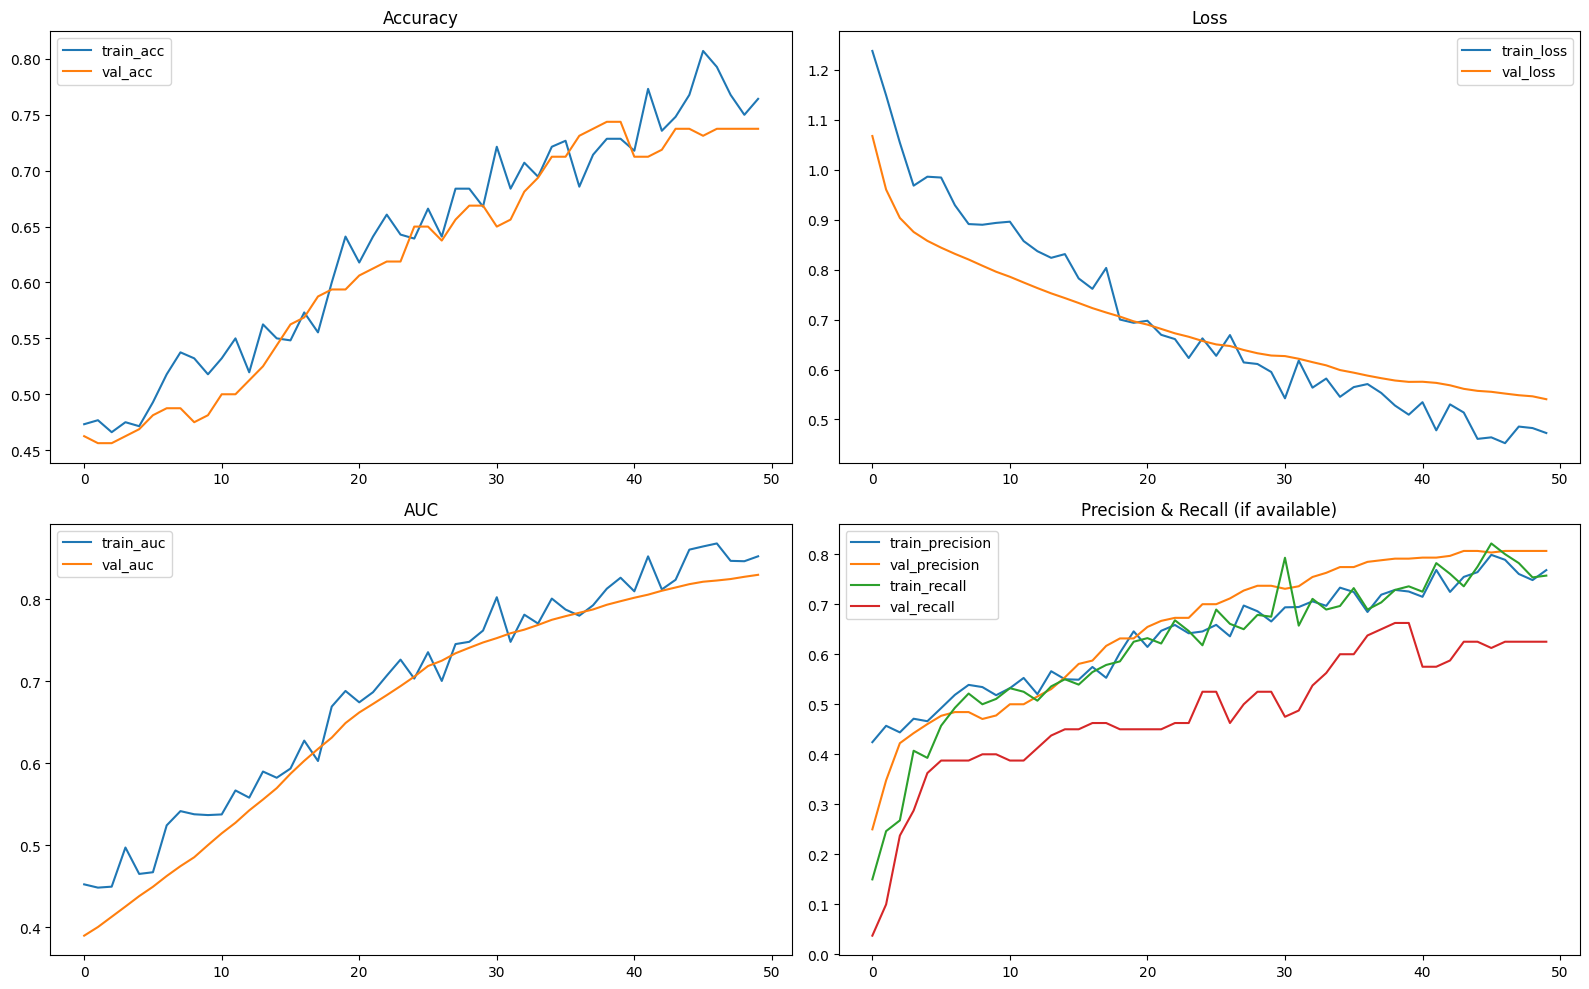

In [ ]:
# -------------------------
# 1) Plot training metrics
# -------------------------
# Kiểm tra keys trong history
print("History keys:", list(history.history.keys()))

# Lấy các metric nếu tồn tại
def get_hist(key):
    return history.history[key] if key in history.history else None

acc = get_hist('accuracy')
val_acc = get_hist('val_accuracy')
loss = get_hist('loss')
val_loss = get_hist('val_loss')
auc = get_hist('auc')
val_auc = get_hist('val_auc')
precision = get_hist('precision')
val_precision = get_hist('val_precision')
recall = get_hist('recall')
val_recall = get_hist('val_recall')

epochs_range = range(len(history.epoch))

# Plot (tùy theo metric có tồn tại hay không)
plt.figure(figsize=(16, 10))

# Accuracy
plt.subplot(2, 2, 1)
if acc is not None:
    plt.plot(epochs_range, acc, label='train_acc')
if val_acc is not None:
    plt.plot(epochs_range, val_acc, label='val_acc')
plt.legend()
plt.title('Accuracy')

# Loss
plt.subplot(2, 2, 2)
if loss is not None:
    plt.plot(epochs_range, loss, label='train_loss')
if val_loss is not None:
    plt.plot(epochs_range, val_loss, label='val_loss')
plt.legend()
plt.title('Loss')

# AUC (nếu có)
plt.subplot(2, 2, 3)
if auc is not None:
    plt.plot(epochs_range, auc, label='train_auc')
if val_auc is not None:
    plt.plot(epochs_range, val_auc, label='val_auc')
plt.legend()
plt.title('AUC')

# Precision/Recall (nếu có) — vẽ chung
plt.subplot(2, 2, 4)
plotted = False
if precision is not None:
    plt.plot(epochs_range, precision, label='train_precision'); plotted=True
if val_precision is not None:
    plt.plot(epochs_range, val_precision, label='val_precision'); plotted=True
if recall is not None:
    plt.plot(epochs_range, recall, label='train_recall'); plotted=True
if val_recall is not None:
    plt.plot(epochs_range, val_recall, label='val_recall'); plotted=True
if plotted:
    plt.legend()
plt.title('Precision & Recall (if available)')

plt.tight_layout()
plt.show()


Test set: 240 samples
Using threshold = 0.22535671293735504


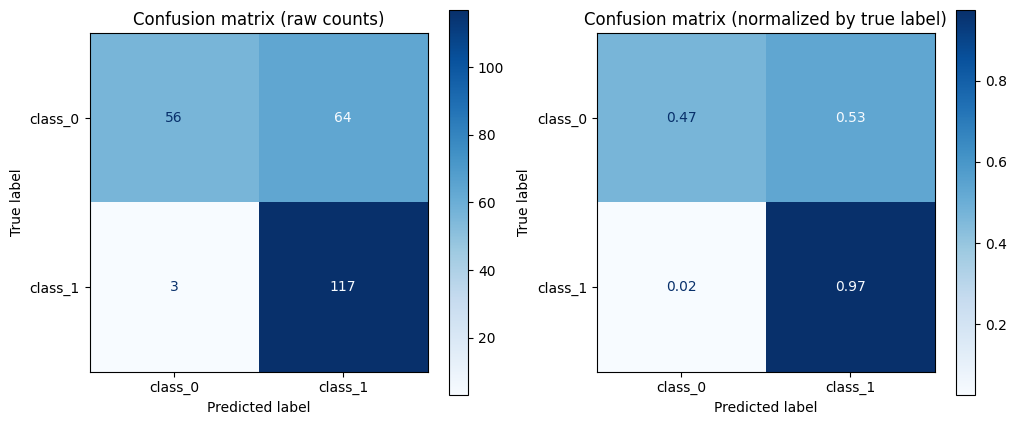


Classification report (threshold = 0.23):

              precision    recall  f1-score   support

         0.0     0.9492    0.4667    0.6257       120
         1.0     0.6464    0.9750    0.7774       120

    accuracy                         0.7208       240
   macro avg     0.7978    0.7208    0.7016       240
weighted avg     0.7978    0.7208    0.7016       240



In [ ]:
# ----------------------------------------------------
# 2) Confusion matrix and classification report on test
# ----------------------------------------------------
# (a) Lấy xác suất và nhãn thật từ test_ds
# Lưu ý: test_ds đã preprocess và shuffle=False khi tạo
preds = (probs > chosen_threshold).astype(int)

# Lấy y_true từ test_ds

print(f"\nTest set: {len(y_true)} samples")
print(f"Using threshold = {chosen_threshold}")

# (b) Confusion matrix
cm = confusion_matrix(y_true, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['class_0','class_1'])
fig, ax = plt.subplots(1,2, figsize=(12,5))
disp.plot(ax=ax[0], values_format='d', cmap=plt.cm.Blues)
ax[0].set_title('Confusion matrix (raw counts)')

# Normalized confusion matrix
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-12)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['class_0','class_1'])
disp_norm.plot(ax=ax[1], values_format='.2f', cmap=plt.cm.Blues)
ax[1].set_title('Confusion matrix (normalized by true label)')
plt.show()

# (c) Classification report
print("\nClassification report (threshold = {:.2f}):\n".format(chosen_threshold))
print(classification_report(y_true, preds, digits=4))

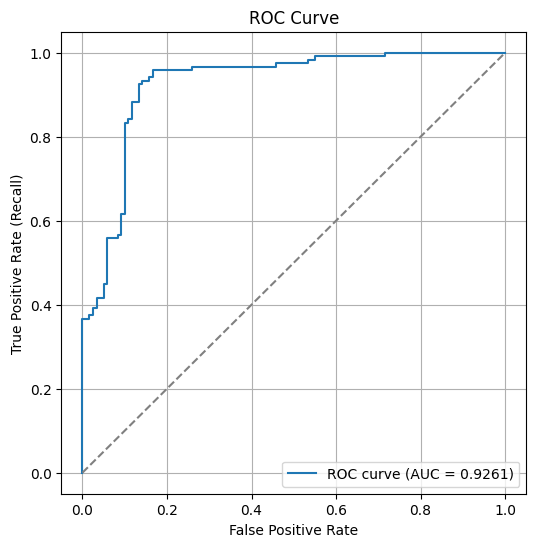

Confusion matrix counts: TN, FP, FN, TP = [ 56  64   3 117]
ROC AUC on test: 0.9261
Sensitivity (Recall): 0.9750, Specificity: 0.4667


In [ ]:
# ----------------------------------------------------
# 3) ROC curve + ROC AUC on test set
# ----------------------------------------------------
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# (Optional) In 1 số chỉ số quan trọng
tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (None,)*4
print("Confusion matrix counts: TN, FP, FN, TP =", cm.ravel() if cm.size==4 else cm)
print(f"ROC AUC on test: {roc_auc:.4f}")
if tp is not None:
    sensitivity = tp / (tp + fn + 1e-12)
    specificity = tn / (tn + fp + 1e-12)
    print(f"Sensitivity (Recall): {sensitivity:.4f}, Specificity: {specificity:.4f}")
